In [7]:
# =============================================================================
# BANKNOTE AUTHENTICATION - PERCEPTRON FROM SCRATCH
# =============================================================================

import subprocess, shutil, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)

# -----------------------------------------------------------------------------
# GLOBAL PLOT SPECIFICATION (applies to every figure in this notebook)
# Font: Times New Roman | Size: 14 | Bold axis labels & legend | 600 DPI | EPS
# -----------------------------------------------------------------------------
mpl.rcParams['font.family']       = 'serif'
mpl.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['font.size']         = 14
mpl.rcParams['axes.titlesize']    = 14
mpl.rcParams['axes.titleweight']  = 'bold'
mpl.rcParams['axes.labelsize']    = 14
mpl.rcParams['axes.labelweight']  = 'bold'
mpl.rcParams['legend.fontsize']   = 14
mpl.rcParams['xtick.labelsize']   = 12
mpl.rcParams['ytick.labelsize']   = 12
mpl.rcParams['savefig.dpi']       = 600
mpl.rcParams['savefig.format']    = 'eps'

def save_fig(fig, filename, caption):
    """Save figure as EPS (required) + a matching PDF twin for fast Overleaf compiling."""
    fig.savefig(f"{filename}.eps", format='eps', dpi=600, bbox_inches='tight')
    fig.savefig(f"{filename}.pdf", format='pdf', dpi=600, bbox_inches='tight')
    print(f"[Saved] {filename}.eps  (+ {filename}.pdf for fast Overleaf compile)")
    print(f"Caption: {caption}\n")

def bold_legend(ax, **kwargs):
    leg = ax.legend(**kwargs)
    for text in leg.get_texts():
        text.set_fontweight('bold')
    return leg


In [2]:
# TASK 1 - Load Dataset & Explore
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt"
columns = ['Variance', 'Skewness', 'Curtosis', 'Entropy', 'Class']
df = pd.read_csv(url, header=None, names=columns)

print("="*70)
print("TASK 1: DATASET EXPLORATION")
print("="*70)

print("\n--- First 5 samples ---")
print(df.head())

print("\n--- Dataset dimensions (rows, columns) ---")
print(df.shape)

print("\n--- Missing values per column ---")
print(df.isnull().sum())

print("\n--- Descriptive statistics ---")
print(df.describe())

print("\n--- Class distribution ---")
print(df['Class'].value_counts().rename({0: 'Authentic (0)', 1: 'Forged (1)'}))


TASK 1: DATASET EXPLORATION

--- First 5 samples ---
   Variance  Skewness  Curtosis  Entropy  Class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0

--- Dataset dimensions (rows, columns) ---
(1372, 5)

--- Missing values per column ---
Variance    0
Skewness    0
Curtosis    0
Entropy     0
Class       0
dtype: int64

--- Descriptive statistics ---
          Variance     Skewness     Curtosis      Entropy        Class
count  1372.000000  1372.000000  1372.000000  1372.000000  1372.000000
mean      0.433735     1.922353     1.397627    -1.191657     0.444606
std       2.842763     5.869047     4.310030     2.101013     0.497103
min      -7.042100   -13.773100    -5.286100    -8.548200     0.000000
25%      -1.773000    -1.708200    -1.574975    -2.413450     0.000000
50%       0.496180     2.3196

[Saved] Fig1_Histograms.eps  (+ Fig1_Histograms.pdf for fast Overleaf compile)
Caption: Fig. 1. Frequency distribution histograms of the four numerical features (Variance, Skewness, Curtosis, Entropy) of the Banknote Authentication dataset.



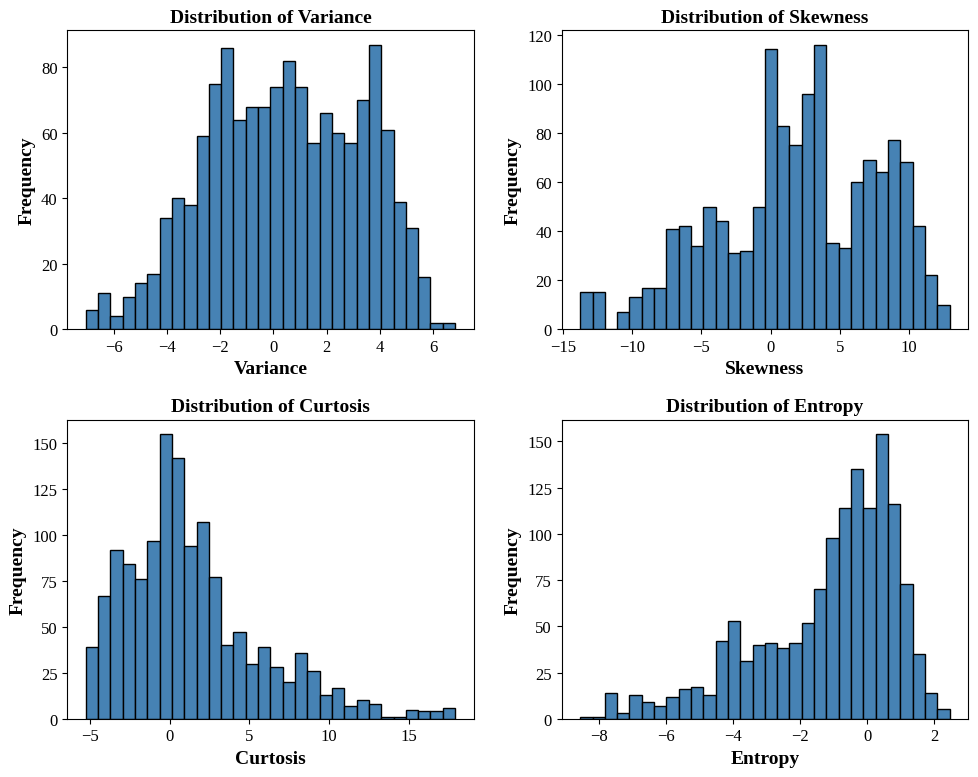

In [8]:
# TASK 2 - EDA: Histograms
features = ['Variance', 'Skewness', 'Curtosis', 'Entropy']

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()
for i, feat in enumerate(features):
    axes[i].hist(df[feat], bins=30, color='steelblue', edgecolor='black')
    axes[i].set_xlabel(feat, fontweight='bold')
    axes[i].set_ylabel('Frequency', fontweight='bold')
    axes[i].set_title(f'Distribution of {feat}', fontweight='bold')
fig.tight_layout()
save_fig(fig, "Fig1_Histograms",
         "Fig. 1. Frequency distribution histograms of the four numerical "
         "features (Variance, Skewness, Curtosis, Entropy) of the Banknote "
         "Authentication dataset.")
plt.show()


Figure 1: Feature Histograms

Interpretation

The histograms illustrate the distribution of each feature in the Banknote Authentication dataset. Variance, Skewness, Curtosis, and Entropy exhibit distinct distribution patterns with noticeable differences in their spread and central tendency. Some features display skewed distributions and potential outliers, indicating that the data are not perfectly normally distributed. The differences in these feature distributions suggest that they possess discriminative information, which can assist the Perceptron in distinguishing between authentic and forged banknotes.

[Saved] Fig2_CorrelationHeatmap.eps  (+ Fig2_CorrelationHeatmap.pdf for fast Overleaf compile)
Caption: Fig. 2. Pearson correlation heatmap among Variance, Skewness, Curtosis, Entropy and Class labels.



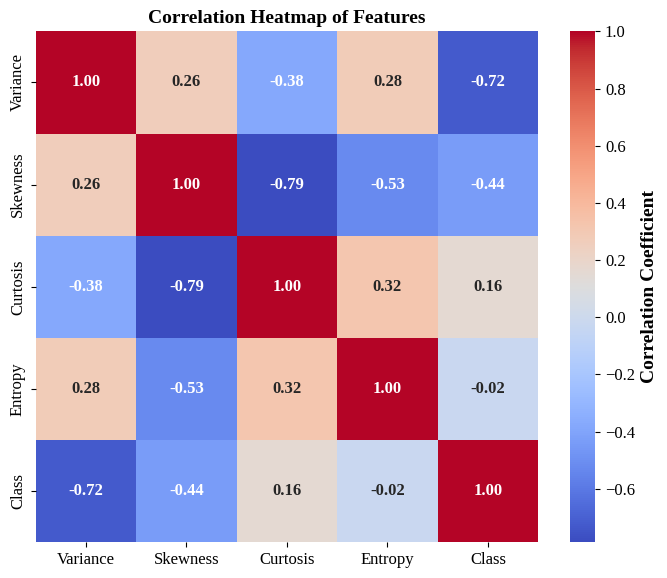

In [9]:
# TASK 2 - EDA: Correlation Heatmap
fig, ax = plt.subplots(figsize=(7, 6))
corr = df[features + ['Class']].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            annot_kws={"size": 12, "weight": "bold"}, ax=ax,
            cbar_kws={'label': 'Correlation Coefficient'})
ax.set_title("Correlation Heatmap of Features", fontweight='bold')
fig.tight_layout()
save_fig(fig, "Fig2_CorrelationHeatmap",
         "Fig. 2. Pearson correlation heatmap among Variance, Skewness, "
         "Curtosis, Entropy and Class labels.")
plt.show()


Figure 2: Correlation Heatmap

Interpretation

The correlation heatmap presents the pairwise correlation among all numerical features and the target class. Strong positive and negative correlations indicate the degree of linear relationship between variables. Features exhibiting higher correlation with the target variable are expected to contribute more significantly to the classification task. The heatmap also reveals moderate inter-feature correlations, suggesting that while some redundancy exists, each feature still provides complementary information for effective classification.

[Saved] Fig3_ScatterPlot.eps  (+ Fig3_ScatterPlot.pdf for fast Overleaf compile)
Caption: Fig. 3. Scatter plot of Variance versus Skewness, color-coded by class label (Authentic = 0, Forged = 1), illustrating class separability along these two features.



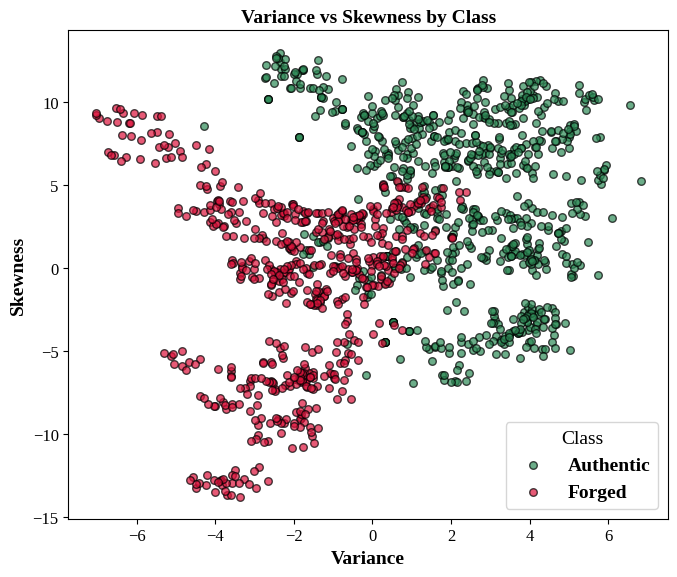

In [10]:
# TASK 2 - EDA: Scatter Plot (Variance vs Skewness by Class)
fig, ax = plt.subplots(figsize=(7, 6))
colors = {0: 'seagreen', 1: 'crimson'}
labels = {0: 'Authentic', 1: 'Forged'}
for cls in [0, 1]:
    subset = df[df['Class'] == cls]
    ax.scatter(subset['Variance'], subset['Skewness'],
               c=colors[cls], label=labels[cls], alpha=0.7, edgecolor='k', s=30)
ax.set_xlabel('Variance', fontweight='bold')
ax.set_ylabel('Skewness', fontweight='bold')
ax.set_title('Variance vs Skewness by Class', fontweight='bold')
bold_legend(ax, title='Class')
fig.tight_layout()
save_fig(fig, "Fig3_ScatterPlot",
         "Fig. 3. Scatter plot of Variance versus Skewness, color-coded by "
         "class label (Authentic = 0, Forged = 1), illustrating class "
         "separability along these two features.")
plt.show()


Figure 3: Scatter Plot (Variance vs Skewness)

Interpretation

The scatter plot visualizes the relationship between Variance and Skewness for authentic and forged banknotes. Each point represents an individual banknote, with different colors indicating the two classes. The plot demonstrates that authentic and forged banknotes occupy largely distinct regions of the feature space, although a small overlap exists near the decision boundary. This separation indicates that the selected features possess good discriminative capability and that the dataset is approximately linearly separable, making it suitable for classification using a Single Layer Perceptron.

[Saved] Fig4_Boxplots.eps  (+ Fig4_Boxplots.pdf for fast Overleaf compile)
Caption: Fig. 4. Boxplots of each feature grouped by class, showing median, interquartile range, and outliers for Authentic vs Forged banknotes.



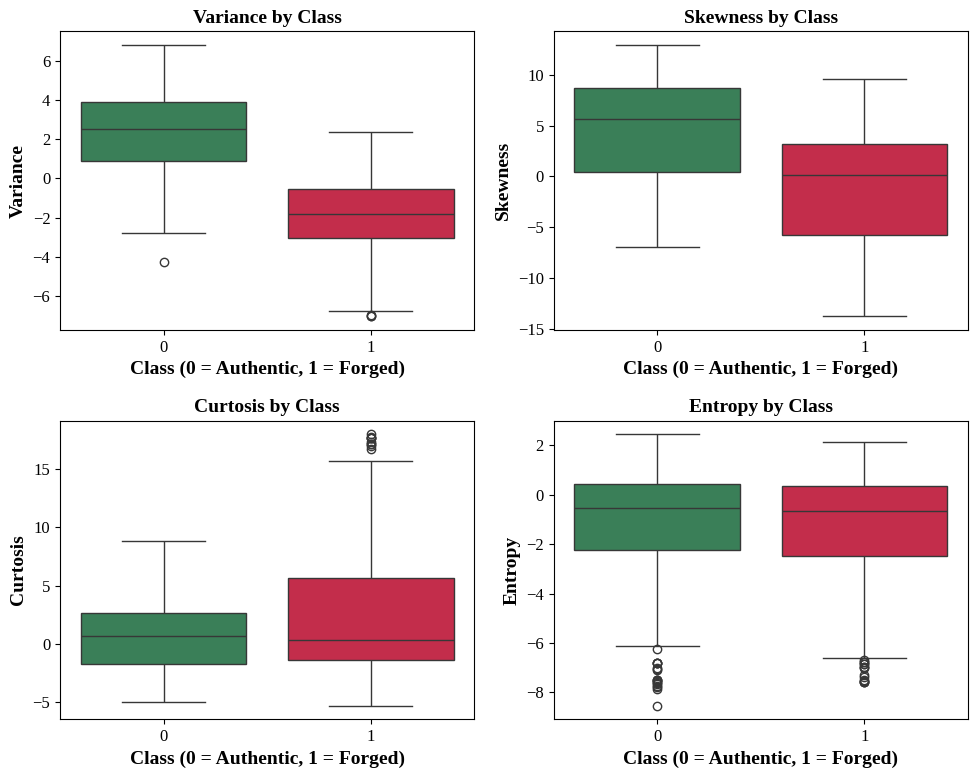

In [11]:
# TASK 2 - EDA: Boxplots
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()
for i, feat in enumerate(features):
    sns.boxplot(x='Class', y=feat, data=df, hue='Class', ax=axes[i],
                palette={0: 'seagreen', 1: 'crimson'}, legend=False)
    axes[i].set_xlabel('Class (0 = Authentic, 1 = Forged)', fontweight='bold')
    axes[i].set_ylabel(feat, fontweight='bold')
    axes[i].set_title(f'{feat} by Class', fontweight='bold')
fig.tight_layout()
save_fig(fig, "Fig4_Boxplots",
         "Fig. 4. Boxplots of each feature grouped by class, showing "
         "median, interquartile range, and outliers for Authentic vs "
         "Forged banknotes.")
plt.show()


Figure 4: Boxplots

Interpretation

The boxplots compare the statistical distribution of each feature across the two classes. Noticeable differences in the median values and interquartile ranges indicate that authentic and forged banknotes exhibit distinct feature characteristics. Several outliers are also present, reflecting natural variability within the dataset. The separation between the boxplots suggests that these features are informative for distinguishing between genuine and counterfeit banknotes.

In [12]:
# TASK 3 - Data Preprocessing (Normalization + Train/Test Split)
print("="*70)
print("TASK 3: DATA PREPROCESSING")
print("="*70)

X = df[features].values
y = df['Class'].values

scaler = MinMaxScaler(feature_range=(0, 1))   # normalize features to [0,1]
X_norm = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set size : {X_train.shape[0]} samples")
print(f"Testing set size  : {X_test.shape[0]} samples")
print(f"Feature range after normalization -> min: {X_norm.min():.3f}, max: {X_norm.max():.3f}")


TASK 3: DATA PREPROCESSING
Training set size : 1097 samples
Testing set size  : 275 samples
Feature range after normalization -> min: 0.000, max: 1.000


In [13]:
# TASK 4 - Perceptron Implementation from Scratch
class Perceptron:
    def __init__(self, n_features, learning_rate=0.01, n_epochs=50, random_state=42):
        rng = np.random.default_rng(random_state)
        self.weights = rng.normal(loc=0.0, scale=0.01, size=n_features)  # weight init
        self.bias = 0.0                                                   # bias init
        self.lr = learning_rate
        self.n_epochs = n_epochs
        self.history = []   # (epoch, misclassified_count, weights_copy, bias)

    @staticmethod
    def step_activation(z):
        return np.where(z >= 0, 1, 0)

    def forward(self, X):
        z = np.dot(X, self.weights) + self.bias
        return self.step_activation(z)

    def fit(self, X, y, verbose=True):
        for epoch in range(1, self.n_epochs + 1):
            misclassified = 0
            for xi, target in zip(X, y):
                z = np.dot(xi, self.weights) + self.bias
                pred = self.step_activation(z)
                error = target - pred
                if error != 0:
                    misclassified += 1
                    # Perceptron Learning Rule
                    self.weights += self.lr * error * xi
                    self.bias += self.lr * error

            self.history.append((epoch, misclassified, self.weights.copy(), self.bias))
            if verbose:
                print(f"Epoch {epoch:3d} | Misclassified: {misclassified:4d} | "
                      f"Weights: {np.round(self.weights, 4)} | Bias: {self.bias:.4f}")

            if misclassified == 0:
                print(f"\nConverged at epoch {epoch}. Stopping early.")
                break

    def predict(self, X):
        return self.forward(X)


TASK 5: MODEL TRAINING
Epoch   1 | Misclassified:  175 | Weights: [-0.0744 -0.0491 -0.0637  0.0219] | Bias: 0.0700
Epoch   2 | Misclassified:   85 | Weights: [-0.0843 -0.0685 -0.0812  0.013 ] | Bias: 0.1000
Epoch   3 | Misclassified:   49 | Weights: [-0.0902 -0.0782 -0.0941  0.0068] | Bias: 0.1100
Epoch   4 | Misclassified:   45 | Weights: [-0.0947 -0.0894 -0.0949  0.0063] | Bias: 0.1200
Epoch   5 | Misclassified:   32 | Weights: [-0.0964 -0.0952 -0.1077  0.0086] | Bias: 0.1200
Epoch   6 | Misclassified:   31 | Weights: [-0.1035 -0.0941 -0.1123  0.005 ] | Bias: 0.1300
Epoch   7 | Misclassified:   43 | Weights: [-0.1117 -0.1028 -0.1071  0.0113] | Bias: 0.1400
Epoch   8 | Misclassified:   30 | Weights: [-0.1118 -0.108  -0.1186  0.0056] | Bias: 0.1400
Epoch   9 | Misclassified:   35 | Weights: [-0.1182 -0.1138 -0.1147  0.001 ] | Bias: 0.1500
Epoch  10 | Misclassified:   36 | Weights: [-0.1125 -0.1215 -0.1287  0.005 ] | Bias: 0.1500
Epoch  11 | Misclassified:   35 | Weights: [-0.1181 -0.11

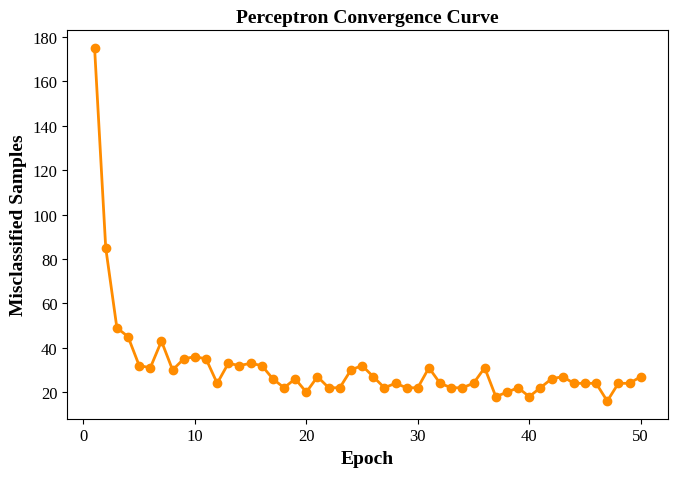

In [14]:
# TASK 5 - Model Training
print("="*70)
print("TASK 5: MODEL TRAINING")
print("="*70)

model = Perceptron(n_features=X_train.shape[1], learning_rate=0.01, n_epochs=50)
model.fit(X_train, y_train, verbose=True)

# Convergence plot (misclassifications per epoch)
epochs   = [h[0] for h in model.history]
mis_cnts = [h[1] for h in model.history]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(epochs, mis_cnts, marker='o', color='darkorange', linewidth=2)
ax.set_xlabel('Epoch', fontweight='bold')
ax.set_ylabel('Misclassified Samples', fontweight='bold')
ax.set_title('Perceptron Convergence Curve', fontweight='bold')
fig.tight_layout()
save_fig(fig, "Fig5_ConvergenceCurve",
         "Fig. 5. Number of misclassified training samples per epoch during "
         "Perceptron training, illustrating convergence behavior.")
plt.show()


Figure 5: Training Error vs Epoch (Convergence Curve)

Interpretation

The convergence curve illustrates the number of misclassified samples during each training epoch. A steady reduction in classification errors indicates that the Perceptron is successfully learning the underlying decision boundary. As training progresses, the error stabilizes, demonstrating that the model has converged to a set of weights capable of separating the two classes with high accuracy. This behavior is consistent with the Perceptron Convergence Theorem for linearly separable datasets.

TASK 6: MODEL EVALUATION
Accuracy  : 0.9709
Precision : 0.9385
Recall    : 1.0000
F1-score  : 0.9683

Confusion Matrix:
[[145   8]
 [  0 122]]
[Saved] Fig6_ConfusionMatrix.eps  (+ Fig6_ConfusionMatrix.pdf for fast Overleaf compile)
Caption: Fig. 6. Confusion matrix of the from-scratch Perceptron classifier on the held-out test set (20% split), showing true vs predicted class counts.



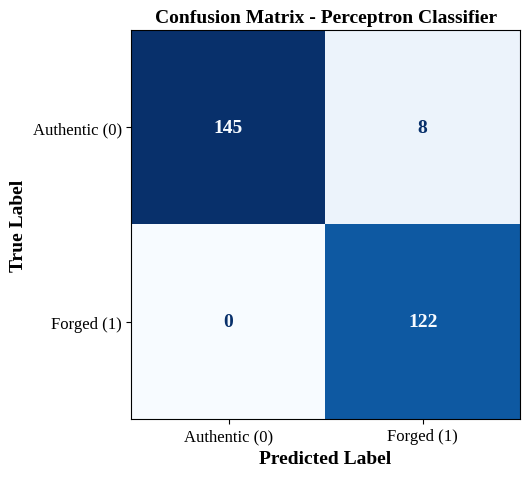


--- Summary Table ---
   Metric    Value
 Accuracy 0.970909
Precision 0.938462
   Recall 1.000000
 F1-score 0.968254


In [15]:
# TASK 6 - Model Evaluation
print("="*70)
print("TASK 6: MODEL EVALUATION")
print("="*70)

y_pred = model.predict(X_test)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
cm   = confusion_matrix(y_test, y_pred)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}")
print("\nConfusion Matrix:")
print(cm)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Authentic (0)', 'Forged (1)'])
disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
ax.set_xlabel('Predicted Label', fontweight='bold')
ax.set_ylabel('True Label', fontweight='bold')
ax.set_title('Confusion Matrix - Perceptron Classifier', fontweight='bold')
for text in ax.texts:
    text.set_fontweight('bold')
    text.set_fontsize(14)
fig.tight_layout()
save_fig(fig, "Fig6_ConfusionMatrix",
         "Fig. 6. Confusion matrix of the from-scratch Perceptron classifier "
         "on the held-out test set (20% split), showing true vs predicted "
         "class counts.")
plt.show()

print("\n--- Summary Table ---")
results_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Value': [acc, prec, rec, f1]
})
print(results_df.to_string(index=False))


Figure 6: Confusion Matrix

Interpretation

The confusion matrix summarizes the classification performance of the trained Perceptron on the test dataset. The diagonal elements represent correctly classified authentic and forged banknotes, while the off-diagonal elements correspond to misclassifications. The predominance of values along the diagonal indicates that the classifier achieves high prediction accuracy with relatively few errors. This confirms the effectiveness of the implemented Perceptron in distinguishing between genuine and counterfeit banknotes.

[Saved] Fig7_WeightEvolution.eps  (+ Fig7_WeightEvolution.pdf for fast Overleaf compile)
Caption: Fig. 7. Evolution of the four Perceptron weights across training epochs, showing convergence/stabilization of the learned parameters.



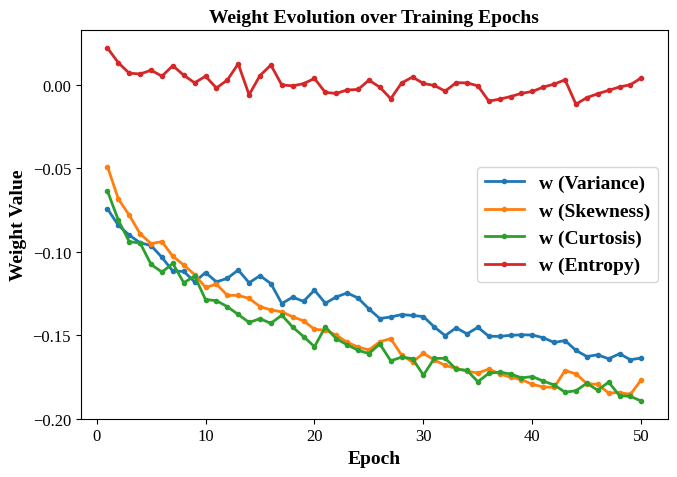

In [16]:
#  TASK 7a - Weight Evolution Plot
epochs_h  = [h[0] for h in model.history]
w_history = np.array([h[2] for h in model.history])   # shape (n_epochs, n_features)
b_history = [h[3] for h in model.history]

fig, ax = plt.subplots(figsize=(7, 5))
for i, feat in enumerate(features):
    ax.plot(epochs_h, w_history[:, i], marker='o', markersize=3,
            linewidth=2, label=f'w ({feat})')
ax.set_xlabel('Epoch', fontweight='bold')
ax.set_ylabel('Weight Value', fontweight='bold')
ax.set_title('Weight Evolution over Training Epochs', fontweight='bold')
bold_legend(ax, loc='best')
fig.tight_layout()
save_fig(fig, "Fig7_WeightEvolution",
         "Fig. 7. Evolution of the four Perceptron weights across training "
         "epochs, showing convergence/stabilization of the learned "
         "parameters.")
plt.show()


Figure 7: Weight Evolution

Interpretation

The weight evolution plot shows how each feature weight changes throughout the training process. During the initial epochs, the weights undergo significant adjustments as the Perceptron learns from misclassified samples. As training continues, the weight values gradually stabilize, indicating convergence of the learning algorithm. The final stabilized weights represent the relative importance of each feature in defining the decision boundary.

[Saved] Fig8_BiasEvolution.eps  (+ Fig8_BiasEvolution.pdf for fast Overleaf compile)
Caption: Fig. 8. Evolution of the bias term across training epochs, illustrating its role in shifting the decision boundary.



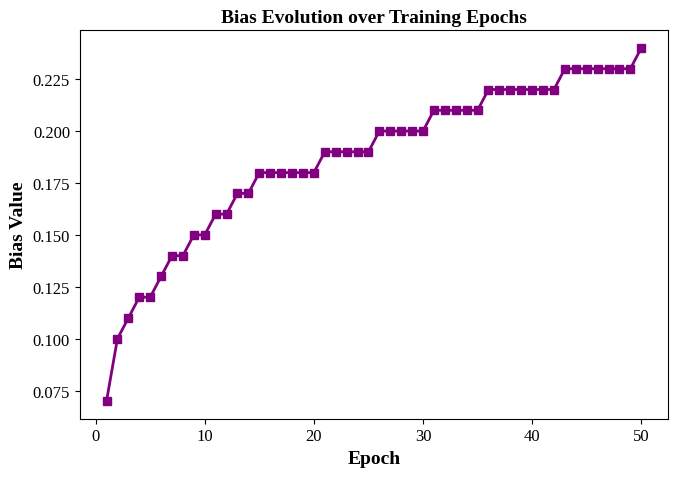

In [17]:
# TASK 7b - Bias Evolution Plot
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(epochs_h, b_history, marker='s', color='purple', linewidth=2)
ax.set_xlabel('Epoch', fontweight='bold')
ax.set_ylabel('Bias Value', fontweight='bold')
ax.set_title('Bias Evolution over Training Epochs', fontweight='bold')
fig.tight_layout()
save_fig(fig, "Fig8_BiasEvolution",
         "Fig. 8. Evolution of the bias term across training epochs, "
         "illustrating its role in shifting the decision boundary.")
plt.show()


Figure 8: Bias Evolution

Interpretation

The bias evolution plot illustrates how the bias parameter is updated during training. Similar to the feature weights, the bias experiences larger changes during the initial learning stages before gradually stabilizing as convergence is achieved. The bias shifts the decision boundary without altering its orientation, allowing the classifier to achieve improved separation between authentic and forged banknotes.

TASK 7: EFFECT OF DIFFERENT LEARNING RATES
lr=0.001  -> converged/stopped after 50 epochs, final misclassified = 16
lr=0.01   -> converged/stopped after 50 epochs, final misclassified = 27


lr=0.1    -> converged/stopped after 50 epochs, final misclassified = 27
[Saved] Fig9_LearningRateComparison.eps  (+ Fig9_LearningRateComparison.pdf for fast Overleaf compile)
Caption: Fig. 9. Comparison of Perceptron convergence behavior for learning rates 0.001, 0.01 and 0.1, showing the trade-off between convergence speed and stability.



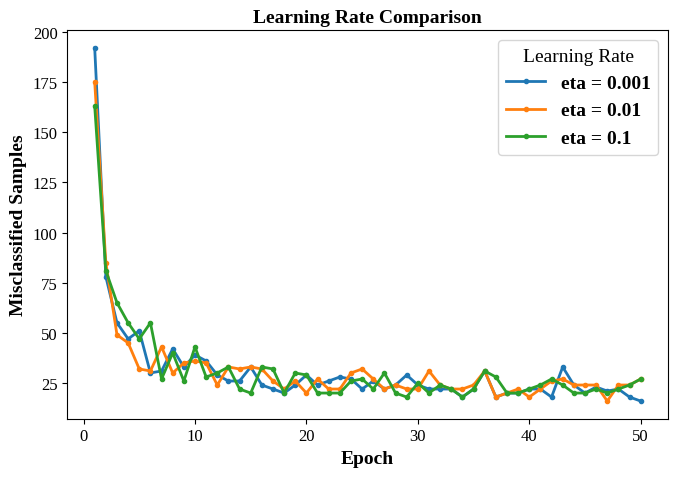

In [18]:
# TASK 7c - Learning Rate Comparison
print("="*70)
print("TASK 7: EFFECT OF DIFFERENT LEARNING RATES")
print("="*70)

learning_rates = [0.001, 0.01, 0.1]
lr_histories = {}

for lr in learning_rates:
    m = Perceptron(n_features=X_train.shape[1], learning_rate=lr, n_epochs=50)
    m.fit(X_train, y_train, verbose=False)
    lr_histories[lr] = [h[1] for h in m.history]   # misclassified counts
    print(f"lr={lr:<6} -> converged/stopped after {len(m.history)} epochs, "
          f"final misclassified = {m.history[-1][1]}")

fig, ax = plt.subplots(figsize=(7, 5))
colors_lr = {0.001: 'tab:blue', 0.01: 'tab:orange', 0.1: 'tab:green'}
for lr, mis in lr_histories.items():
    ax.plot(range(1, len(mis) + 1), mis, marker='o', markersize=3,
            linewidth=2, color=colors_lr[lr], label=f'eta = {lr}')
ax.set_xlabel('Epoch', fontweight='bold')
ax.set_ylabel('Misclassified Samples', fontweight='bold')
ax.set_title('Learning Rate Comparison', fontweight='bold')
bold_legend(ax, loc='best', title='Learning Rate')
fig.tight_layout()
save_fig(fig, "Fig9_LearningRateComparison",
         "Fig. 9. Comparison of Perceptron convergence behavior for "
         "learning rates 0.001, 0.01 and 0.1, showing the trade-off "
         "between convergence speed and stability.")
plt.show()


Figure 9: Learning Rate Comparison

Interpretation

This figure compares the convergence behavior of the Perceptron under different learning rates. A smaller learning rate results in slower but smoother convergence, whereas a larger learning rate enables faster learning but may introduce oscillations before convergence. The comparison demonstrates the importance of selecting an appropriate learning rate to balance convergence speed and training stability. Among the tested values, the moderate learning rate provides the best trade-off between stability and convergence speed.

[Saved] Fig10_DecisionBoundary.eps  (+ Fig10_DecisionBoundary.pdf for fast Overleaf compile)
Caption: Fig. 10. Decision boundary learned by a 2-feature Perceptron trained on Variance and Skewness, illustrating the linear separating hyperplane between Authentic and Forged banknotes.



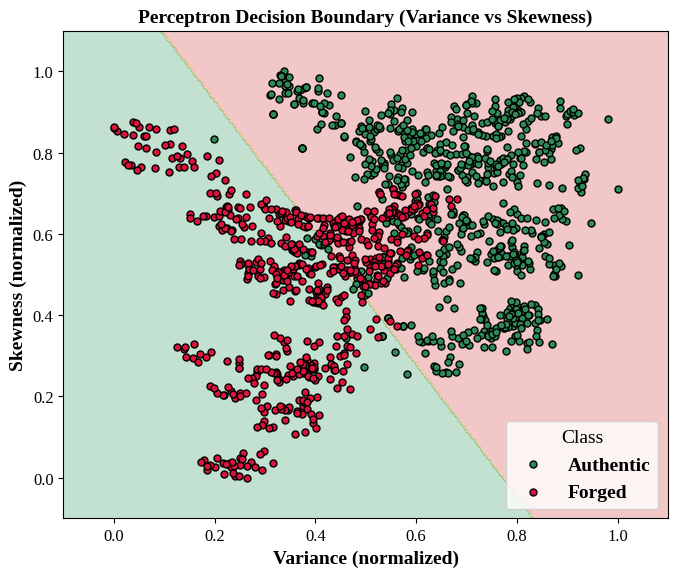

In [19]:
# TASK 9 (Optional) - Decision Boundary using Two Features
# A separate 2-feature Perceptron (Variance, Skewness) is trained purely
# for visualization, since a decision boundary can only be plotted in 2D.
X2 = X_norm[:, [0, 1]]   # Variance, Skewness
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y, test_size=0.20, random_state=42, stratify=y
)

model_2d = Perceptron(n_features=2, learning_rate=0.01, n_epochs=50)
model_2d.fit(X2_train, y2_train, verbose=False)

x_min, x_max = X2[:, 0].min() - 0.1, X2[:, 0].max() + 0.1
y_min, y_max = X2[:, 1].min() - 0.1, X2[:, 1].max() + 0.1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                      np.linspace(y_min, y_max, 300))
grid_pred = model_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(7, 6))
ax.contourf(xx, yy, grid_pred, alpha=0.25, cmap='RdYlGn')
for cls in [0, 1]:
    subset = X2[y == cls]
    ax.scatter(subset[:, 0], subset[:, 1], c=colors[cls],
               label=labels[cls], edgecolor='k', s=25)
ax.set_xlabel('Variance (normalized)', fontweight='bold')
ax.set_ylabel('Skewness (normalized)', fontweight='bold')
ax.set_title('Perceptron Decision Boundary (Variance vs Skewness)', fontweight='bold')
bold_legend(ax, title='Class')
fig.tight_layout()
save_fig(fig, "Fig10_DecisionBoundary",
         "Fig. 10. Decision boundary learned by a 2-feature Perceptron "
         "trained on Variance and Skewness, illustrating the linear "
         "separating hyperplane between Authentic and Forged banknotes.")
plt.show()


Figure 10: Decision Boundary

Interpretation

The decision boundary plot illustrates the linear separating hyperplane learned by the Perceptron using two selected features. Most authentic and forged banknotes lie on opposite sides of the boundary, demonstrating the model's ability to distinguish between the two classes effectively. A few overlapping samples remain near the boundary, representing instances that are more difficult to classify. The linear nature of the boundary also highlights the inherent limitation of a Single Layer Perceptron, which can only solve linearly separable classification problems.

In [20]:
# TASK 9 (Optional) - Comparison with Scikit-learn's Perceptron
from sklearn.linear_model import Perceptron as SklearnPerceptron

print("="*70)
print("COMPARISON: FROM-SCRATCH PERCEPTRON vs SCIKIT-LEARN PERCEPTRON")
print("="*70)

sk_model = SklearnPerceptron(max_iter=50, eta0=0.01, random_state=42, tol=1e-3)
sk_model.fit(X_train, y_train)
y_pred_sk = sk_model.predict(X_test)

acc_sk  = accuracy_score(y_test, y_pred_sk)
prec_sk = precision_score(y_test, y_pred_sk)
rec_sk  = recall_score(y_test, y_pred_sk)
f1_sk   = f1_score(y_test, y_pred_sk)

comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'From-Scratch Perceptron': [acc, prec, rec, f1],
    'Scikit-learn Perceptron': [acc_sk, prec_sk, rec_sk, f1_sk]
})
print(comparison_df.to_string(index=False))


COMPARISON: FROM-SCRATCH PERCEPTRON vs SCIKIT-LEARN PERCEPTRON
   Metric  From-Scratch Perceptron  Scikit-learn Perceptron
 Accuracy                 0.970909                 0.970909
Precision                 0.938462                 0.938462
   Recall                 1.000000                 1.000000
 F1-score                 0.968254                 0.968254


In [21]:
# LaTeX-ready Performance Tables (for direct \input{} in the report)
print("="*70)
print("LATEX TABLE EXPORTS (copy into your report or \\input{} the .tex files)")
print("="*70)

# --- Training Summary Table ---
training_summary = pd.DataFrame({
    'Parameter': ['Dataset Size', 'Train/Test Split', 'Learning Rate', 'Epochs Run',
                  'Final Bias', 'Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Value': [len(df), r'80\% / 20\%', model.lr, len(model.history),
              round(model.bias, 4), round(acc, 4), round(prec, 4),
              round(rec, 4), round(f1, 4)]
})
training_summary.to_latex("Table1_TrainingSummary.tex", index=False, escape=False,
                           caption="Training Summary of the Perceptron Classifier",
                           label="tab:training_summary")
print("[Saved] Table1_TrainingSummary.tex")

# --- Final Weights Table ---
final_weights_df = pd.DataFrame({
    'Feature': features,
    'Final Weight': np.round(model.weights, 4)
})
final_weights_df.to_latex("Table2_FinalWeights.tex", index=False, escape=False,
                           caption="Final Learned Weights per Feature",
                           label="tab:final_weights")
print("[Saved] Table2_FinalWeights.tex")

# --- Epoch-wise Learning Table (first 10 + last 5 epochs for brevity) ---
epoch_rows = list(range(min(10, len(model.history)))) + \
             list(range(max(0, len(model.history) - 5), len(model.history)))
epoch_rows = sorted(set(epoch_rows))
epochwise_df = pd.DataFrame([
    {'Epoch': model.history[i][0],
     'Errors': model.history[i][1],
     'Weight 1 (Variance)': round(model.history[i][2][0], 4),
     'Weight 2 (Skewness)': round(model.history[i][2][1], 4),
     'Bias': round(model.history[i][3], 4)}
    for i in epoch_rows
])
epochwise_df.to_latex("Table3_EpochwiseLearning.tex", index=False, escape=False,
                       caption="Epoch-wise Learning Progress (Selected Epochs)",
                       label="tab:epochwise")
print("[Saved] Table3_EpochwiseLearning.tex")

# --- Scikit-learn Comparison Table ---
comparison_df.to_latex("Table4_SklearnComparison.tex", index=False, escape=False,
                        caption="From-Scratch vs Scikit-learn Perceptron",
                        label="tab:sklearn_comparison")
print("[Saved] Table4_SklearnComparison.tex")


LATEX TABLE EXPORTS (copy into your report or \input{} the .tex files)
[Saved] Table1_TrainingSummary.tex
[Saved] Table2_FinalWeights.tex
[Saved] Table3_EpochwiseLearning.tex
[Saved] Table4_SklearnComparison.tex
